# Python | **Regressão**
*Prof. Luciano Pedroso*

**Objetivo**

Desenvolver algoritmo de regressão para prever qual sera o faturamento da empresa

### Import Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Criando Data Frame

In [2]:
# Para reprodutibilidade
np.random.seed(42)

# Número de amostras
n = 200

# Variáveis independentes
x1 = np.random.randint(10, 100, n)   # preço unitário
x2 = np.random.randint(50, 500, n)   # demanda
x3 = np.random.normal(100, 10, n)    # custo fixo (quase sem correlação)
x4 = x2 * 0.7 - np.random.normal(0, 100, n)  # variável multicolinear com demanda (x2)
x5 = x2 * 0.7 + np.random.normal(0, 15, n)

# Variável target criada como combinação linear com ruído
y = 2 * x1 + 3 * x2 + 1.5 * x4 + np.random.normal(0, 50, n)

# Construir DataFrame
df = pd.DataFrame({
    "Preco_Unitario": x1,
    "Demanda": x2,
    "Custo_Fixo": x3,
    "Marketing": x4,
    "Temperatura": x5,
    "Faturamento": y
})

df.head()

,Preco_Unitario,Demanda,Custo_Fixo,Marketing,Temperatura,Faturamento
0,61,435,91.161426,475.813453,300.451876,2138.742422
1,24,436,101.537251,169.812763,290.518544,1644.794179
2,81,162,100.582087,124.853985,106.735601,836.696896
3,70,150,88.570297,-18.781631,110.659507,563.315360
4,30,162,103.577874,272.842766,124.754829,1002.178339


### Plot Matriz Correlação

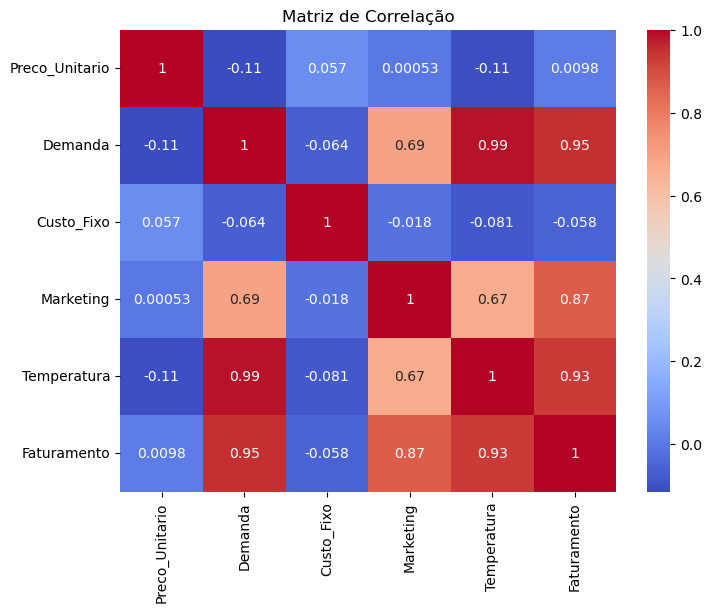

In [3]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

### Analise e Tratamento de Outliers

In [4]:
df.columns

Index(['Preco_Unitario', 'Demanda', 'Custo_Fixo', 'Marketing', 'Temperatura',
       'Faturamento'],
      dtype='object')

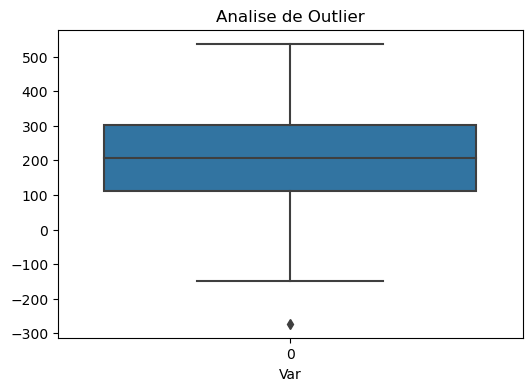

In [5]:
# Boxplot da idade
plt.figure(figsize=(6,4))
sns.boxplot(df['Marketing'])
plt.title("Analise de Outlier")
plt.xlabel("Var")
plt.show()

In [6]:
def substituir_outliers_por_mediana(df, cols=None, ignore_cols=["Faturamento"]):
    if cols is None:
        cols = df.select_dtypes(include=["number"]).columns  # apenas numéricas

    # Remove as colunas ignoradas da lista
    cols = [c for c in cols if c not in ignore_cols]

    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        mediana = df_clean[col].median()

        # Substitui valores fora do limite
        df_clean.loc[df_clean[col] < lower, col] = mediana
        df_clean.loc[df_clean[col] > upper, col] = mediana
    
    return df_clean

### Escolher Variaveis de Entreada

In [7]:
X = df[["Demanda",
    "Custo_Fixo",
    "Marketing" ]]

y = df["Faturamento"]

### Normalização do dados

Normalizar dados significa ajustar as variáveis para que fiquem em uma escala comparável, geralmente entre 0 e 1 ou com média 0 e desvio padrão 1 (padronização).

In [8]:
# Importante para algoritmos baseados em distância (KNN) e gradientes
scaler = MinMaxScaler()  # escala os dados entre 0 e 1
X_scaled = scaler.fit_transform(X)

print("Antes da normalização (primeira linha):", X.iloc[0].values)
print("Depois da normalização (primeira linha):", X_scaled[0])

Antes da normalização (primeira linha): [435.          91.16142564 475.81345291]
Depois da normalização (primeira linha): [0.86098655 0.33231044 0.92442587]


### Dividindo Dados de Treino de Teste

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

### Treinamento do Algoritmo

In [11]:
# Regressão Linear
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Regressão Polinomial (grau 2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

#poly_reg = LinearRegression()
#poly_reg.fit(X_train_poly, y_train)

# Árvore de Decisão
tree = DecisionTreeRegressor(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

# KNN Regressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsRegressor()

### Avaliando Resultados

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def avaliar_modelo(model, Xtr, ytr, Xts, yts, nome):
    pred_train = model.predict(Xtr)
    pred_test = model.predict(Xts)
    
    resultados = {
        "Modelo": nome,
        
        # Erro Absoluto
        "Erro Absoluto (Treino)": np.sum(np.abs(ytr - pred_train)),
        "Erro Absoluto (Teste)": np.sum(np.abs(yts - pred_test)),
        
        # Erro Absoluto Médio (MAE)
        "MAE_Treino": mean_absolute_error(ytr, pred_train),
        "MAE_Teste": mean_absolute_error(yts, pred_test),
        
        # Erro Quadrático Médio (MSE)
        "MSE_Treino": mean_squared_error(ytr, pred_train),
        "MSE_Teste": mean_squared_error(yts, pred_test),
        
        # Erro Relativo Médio
        "Erro Relativo Médio (Treino)": np.mean(np.abs((ytr - pred_train) / ytr)),
        "Erro Relativo Médio (Teste)": np.mean(np.abs((yts - pred_test) / yts))
    }
    return resultados


resultados = []
resultados.append(avaliar_modelo(lin_reg, X_train, y_train, X_test, y_test, "Linear"))
resultados.append(avaliar_modelo(poly_reg, X_train_poly, y_train, X_test_poly, y_test, "Polinomial Grau 2"))
resultados.append(avaliar_modelo(tree, X_train, y_train, X_test, y_test, "Árvore Decisão"))
resultados.append(avaliar_modelo(knn, X_train, y_train, X_test, y_test, "KNN"))

df_resultados = pd.DataFrame(resultados)
print("\nResultados das métricas:")
df_resultados


Resultados das métricas:


,Modelo,Erro Absoluto (Treino),Erro Absoluto (Teste),MAE_Treino,MAE_Teste,MSE_Treino,MSE_Teste,Erro Relativo Médio (Treino),Erro Relativo Médio (Teste)
0,Linear,7513.735550,3251.691896,53.669540,54.194865,4441.792838,4477.727443,0.053887,0.067288
1,Polinomial Grau 2,7384.547480,3629.993190,52.746768,60.499886,4232.803161,5697.999214,0.053980,0.084522
2,Árvore Decisão,13603.030084,8261.550013,97.164501,137.692500,13822.179259,29473.071697,0.111743,0.211518
3,KNN,8191.547806,4177.306077,58.511056,69.621768,5530.231797,9104.709189,0.074023,0.138476


Discussão: Overfitting e Underfitting
    
"""
Overfitting: quando o modelo aprende tão bem os dados de treino que perde a capacidade de generalização 
para dados novos (erros de treino baixos, mas erros de teste altos).

Underfitting: quando o modelo é simples demais e não consegue capturar o padrão dos dados 
(erros altos tanto em treino quanto em teste).

Podemos usar a comparação entre MAE/MSE no treino e no teste para avaliar isso.
"""
